## **Gradiente Descencente (Machine Learning)**

EM Machine Learning, deseja-se encontrar os parâmetros que minimizam uma função de custo.

Considere o seguinte dataset:

$$
V = \{(\mathbf{x}_i, y_i)\}
\quad \text{onde }
\mathbf{x}_i \in \mathbb{R}^{D}
\text{ e }
y_i \in \mathbb{R}
$$

Defimos a função objetivo como sendo a média da perda sobre os dados:

$$
J(\mathbf{\theta}) = \frac{1}{N} \cdot \displaystyle\sum_{i = 1}^{N} L(f(\mathbf{x}_i, \mathbf{\theta}), y_i)
$$

onde:
*   $f(\mathbf{x}_i, \mathbf{\theta})$ é o modelo parametrizado
*   $L$ é a função perda

O objetivo consiste em:

$$
\min_{\mathbf{\theta}} J(\mathbf{\theta})
$$

Para isso, utiliza o gradiente descendente definido como segue:

$$
\mathbf{\theta}^{(t+1)} = \mathbf{\theta}^{(t)} - \eta \nabla J(\mathbf{\theta}^{(t)})
$$

onde:

*   $\nabla J(\mathbf{\theta})$ é o gradiente da função de custo
*   $\eta$ é a taxa de aprendizado
*   $t$ é o número da iteração

dada a seguinte igualdade:

$$
\nabla J(\mathbf{\theta}) = \frac{1}{N} \cdot \displaystyle\sum_{i = 1}^{N}\nabla L_i (\mathbf{\theta}) \quad
\text{onde} \quad
L_i = L(f(\mathbf{x}_i, \mathbf{\theta}), y_i)
$$

segue que outro modo de escrever a equação acima é:

$$
\mathbf{\theta}^{(t+1)} = \mathbf{\theta}^{(t)} - \eta \cdot \frac{1}{N} \cdot \displaystyle\sum_{i = 1}^{N} \nabla L_i \left(\mathbf{\theta}^{(t)}\right)
$$

esse é o famoso gradiente descendente para uma função de custo $J$.

## **Aplicação do Gradiente Descendente**

Vamos aplicar o método do GD para tarefa de **classificação binária** usando **Regressão Logística** no dataset **Breast Cancer Wisconsin**.

#### **Processamentos dos Dados**

In [215]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

In [216]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (569, 30)
Shape de y: (569,)


In [217]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [218]:
print("Nomes das Classes:")
for name in data.target_names:
  print(name)

Nomes das Classes:
malignant
benign


In [219]:
df["target"].value_counts()

,count
target,
1,357
0,212


In [220]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (455, 30)
Teste: (114, 30)


In [221]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [222]:
def add_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack((ones, X))

X_train = add_bias(X_train)
X_test = add_bias(X_test)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (455, 31)
Teste: (114, 31)


In [223]:
n_features = X_train.shape[1]

beta = np.zeros(n_features)

#### **Implementação do GD e da Regressão Logística Binária**

É preciso lembrar que a Regressão Logística utiliza a **função sigmóide**:

$$
\sigma(x_i^{\top}\beta) = \frac{1}{1 + e^{-(x_i^{\top}\beta)}}
$$

e a função de **entropia cruzada**:

$$
J(\beta) = -\dfrac{1}{N} \sum_{i=1}^{n} y_i\log \sigma(x_i^{\top}\beta) + (1 - y_i)\log (1 - \sigma(x_i^{\top}\beta))
$$

Dado que queremos otimizar $J(\beta)$, usamos o método do GD dado por:

$$
\beta^{(t+1)} = \beta^{(t)} - \eta \cdot \dfrac{1}{N}\cdot X^{\top}(y - p)
$$

Agora podemos seguir no código.

In [224]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_proba(X, w):
    z = X @ w
    return sigmoid(z)

def compute_loss(X, y, beta):

    p = predict_proba(X, beta)

    # evitar log(0)
    epsilon = 1e-15
    p = np.clip(p, epsilon, 1 - epsilon)

    J = -np.mean(
        y * np.log(p) + (1 - y) * np.log(1 - p)
    )

    return J

def compute_gradient(X, y, beta):

    n = len(y)

    p = predict_proba(X, beta)

    gradient = (X.T @ (p - y)) / n

    return gradient

In [225]:
def train_gd(X, y, beta, eta=0.01, epochs=1000):

    losses = []

    for epoch in range(epochs):

        grad = compute_gradient(X, y, beta)

        beta = beta - eta * grad

        loss = compute_loss(X, y, beta)
        losses.append(loss)

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss:.4f}")

    return beta, losses

In [226]:
beta, losses = train_gd(
    X_train,
    y_train,
    beta,
    eta=0.01,
    epochs=1000
)

Epoch 0 | Loss: 0.6730
Epoch 100 | Loss: 0.2436
Epoch 200 | Loss: 0.1818
Epoch 300 | Loss: 0.1537
Epoch 400 | Loss: 0.1371
Epoch 500 | Loss: 0.1258
Epoch 600 | Loss: 0.1176
Epoch 700 | Loss: 0.1113
Epoch 800 | Loss: 0.1063
Epoch 900 | Loss: 0.1021


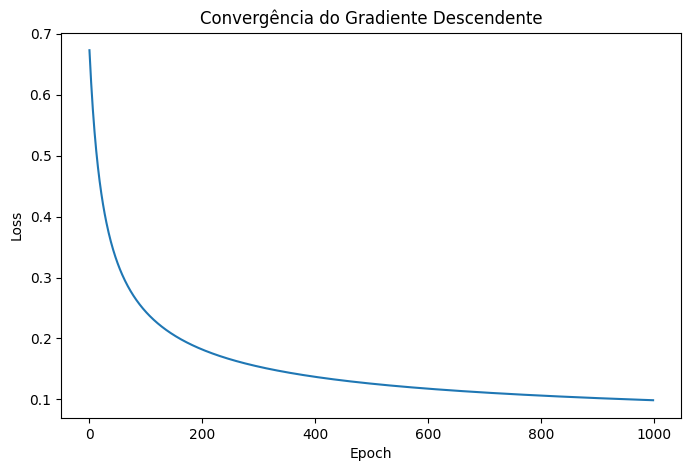

In [227]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Convergência do Gradiente Descendente")
plt.show()

In [228]:
def predict(X, beta, threshold=0.5):

    p = predict_proba(X, beta)

    return (p >= threshold).astype(int)

y_pred = predict(X_test, beta)

accuracy = np.mean(y_pred == y_test)

print(f"Accuracy: {100 * accuracy.round(4)}%")

Accuracy: 97.37%


#### **Visualização dos dados com PCA**

In [229]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train[:,1:])

In [230]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["target"] = y_train

print(pca_df)

          PC1       PC2  target
0   -4.167251  0.255512       1
1    4.597260 -0.967634       0
2   -4.564327 -0.171496       1
3   -0.883693  0.438912       1
4   -2.951399  0.365633       1
..        ...       ...     ...
450 -0.358376 -0.987042       0
451  6.684054 -1.694821       0
452  4.071484  2.643223       0
453  3.303909 -0.200628       0
454 -1.946878  1.929258       1

[455 rows x 3 columns]


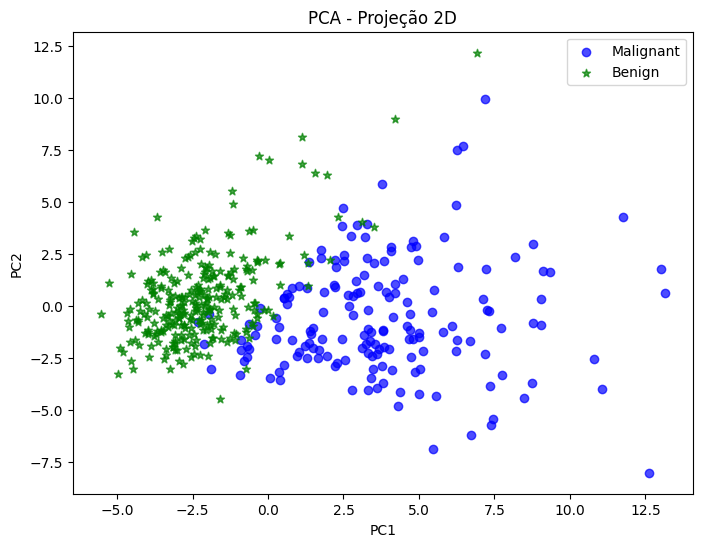

In [231]:
plt.figure(figsize=(8,6))

mask0 = y_train == 0
mask1 = y_train == 1

plt.scatter(X_pca[mask0,0], X_pca[mask0,1], marker='o', color='blue', label="Malignant", alpha=0.7)
plt.scatter(X_pca[mask1,0], X_pca[mask1,1], marker='*', color='green', label="Benign", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Projeção 2D")
plt.legend()

plt.show()

#### **Predição de um novo paciente**

In [232]:
x_new = X_test[0]
y_true = y_test[0]

prob = predict_proba(x_new.reshape(1, -1), beta)[0].round(4)
pred_class = predict(x_new.reshape(1, -1), beta)[0]

class_names = {0: "Malignant", 1: "Benign"}

print("Probabilidade prevista:", prob)
print("Classe prevista:", pred_class, "-", class_names[pred_class])
print("Classe real:", y_true, "-", class_names[y_true])

Probabilidade prevista: 0.0001
Classe prevista: 0 - Malignant
Classe real: 0 - Malignant


In [233]:
x_new = x_new[1:].reshape(1, -1)

x_new_pca = pca.transform(x_new)

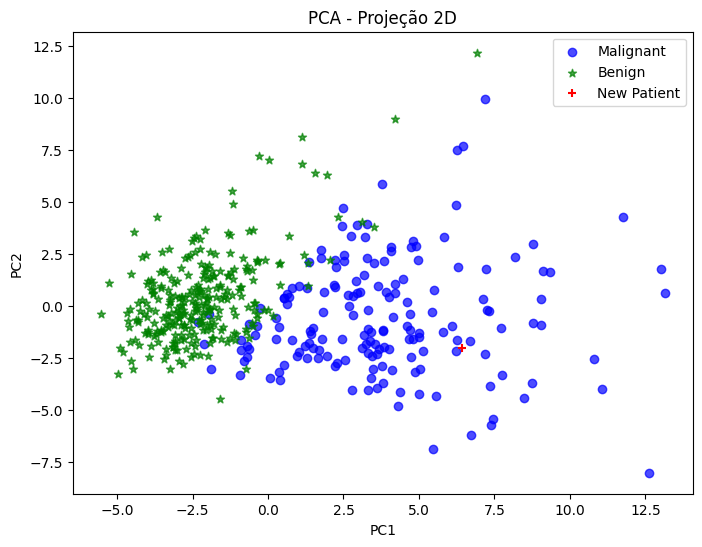

In [234]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[mask0,0], X_pca[mask0,1], marker='o', color='blue', label="Malignant", alpha=0.7)
plt.scatter(X_pca[mask1,0], X_pca[mask1,1], marker='*', color='green', label="Benign", alpha=0.7)

plt.scatter(
    x_new_pca[0, 0],
    x_new_pca[0, 1],
    marker='+',
    color='red',
    label='New Patient',
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Projeção 2D")
plt.legend()
plt.show()